# BRAM fill: paired vs unpaired `mark_bram(7,5)`

Two builds of the same checkpoint differing only in `pair_within_stage`,
measuring how full each physical RAMB ends up post-route. Produces
`bram_fill_stats.csv` and `bram_fill_compare.png` (pairing roughly doubles
per-tile fill at identical function).

**To run:** edit the config cell below — `VIVADO_SETTINGS`, checkpoint and
dataset paths (the BRAM dump uses `dump_bram.tcl` from the original
`jsc150/da4ml_grid/` tree, located via the configured path). Two
place-and-route jobs. The final cocotb cross-check is optional and skips
itself when cocotb is not installed.

In [1]:
import os
os.environ.setdefault('KERAS_BACKEND', 'jax')
os.environ.setdefault('XLA_PYTHON_CLIENT_MEM_FRACTION', '0.5')

import sys
from pathlib import Path

CHECKPOINT_N64 = Path(
    '../../../models/jsc_plf/64-16/'
    'epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534.keras'
)
FEATURES        = 16
MODEL_NAME      = 'jsc'
PART_NAME       = 'xczu7ev-ffvc1156-2-e'
CLOCK_PERIOD    = 2.5
LATENCY_CUTOFF  = 2.0
BRAM_THR        = (7, 5)     # (bw_in_threshold, bw_out_threshold)

TRACE_BATCH     = 2048
MAX_VIVADO_PAR  = 2
VIVADO_SETTINGS = '/tools/Xilinx/2025.1/Vivado/settings64.sh'
RUN_VIVADO      = True

# (variant label, pair_within_stage)
VARIANTS = [
    ('unpaired', False),
    ('paired',   True),
]

HGQ_JSC150 = Path('..').resolve()  # shared helpers: model.py, data.py, dump_bram.tcl
DATA_DIR   = Path('../../../dataset/jsc_plf').resolve()  # from prepare_datasets.sh
NB_DIR     = Path('.').resolve()
DUMP_TCL   = (HGQ_JSC150 / 'dump_bram.tcl').resolve()
if str(HGQ_JSC150) not in sys.path:
    sys.path.insert(0, str(HGQ_JSC150))

# RAMB primitive capacities (data + parity bits).
RAMB_BITS = {
    'RAMB18E2': 16 * 1024 + 2 * 1024,
    'RAMB36E2': 32 * 1024 + 4 * 1024,
    'FIFO18E2': 16 * 1024 + 2 * 1024,
    'FIFO36E2': 32 * 1024 + 4 * 1024,
}

print(f'Config     : N=64  part={PART_NAME}  T={CLOCK_PERIOD} ns  mark_bram={BRAM_THR}')
print(f'Variants   : {[v[0] for v in VARIANTS]}')
print(f'dump_bram  : {DUMP_TCL}  (exists={DUMP_TCL.exists()})')
print(f'Output dir : {NB_DIR}')


Config     : N=64  part=xczu7ev-ffvc1156-2-e  T=2.5 ns  mark_bram=(7, 5)
Variants   : ['unpaired', 'paired']
dump_bram  : /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/da4ml_grid/dump_bram.tcl  (exists=True)
Output dir : /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/bram_fill


Load the cached pre-traced checkpoint.

In [2]:
import keras
from model import SameDim0
from data import get_data
from hgq.utils import trace_minmax

raw_ckpt = CHECKPOINT_N64.expanduser().resolve()
traced   = raw_ckpt.parent / f'model_traced_n64_f{FEATURES}.keras'
if not traced.exists():
    print('No cached traced checkpoint; running trace_minmax...')
    raw = keras.models.load_model(raw_ckpt, compile=False, custom_objects={'SameDim0': SameDim0})
    (X_train, _), (X_val, _), _ = get_data(DATA_DIR, 64, FEATURES == 3)
    trace_minmax(raw, X_train, batch_size=TRACE_BATCH, reset=True,  verbose=True)
    trace_minmax(raw, X_val,   batch_size=TRACE_BATCH, reset=False, verbose=True)
    raw.save(traced)

model = keras.models.load_model(traced, compile=False, custom_objects={'SameDim0': SameDim0})
model_stem = raw_ckpt.stem
print(f'Loaded N={model.input_shape[1]} F={model.input_shape[-1]}')


Loaded N=64 F=16


Build both variants; fresh project dir per variant.

In [3]:
import shutil
import re
import numpy as np
from da4ml.cmvm import dsp_offload
from da4ml.converter import trace_model
from da4ml.trace import HWConfig, comb_trace, mark_bram, mark_dsp
from da4ml.codegen import RTLModel

HW_CONFIG      = HWConfig(1, -1, -1)
DSP_OFFLOAD_FN = dsp_offload(min_csd_terms=2, min_var_bits=4, max_const_bits=18, max_ops=None)
SOLVER_OPTIONS = {'hard_dc': 2, 'dsp_offload_fn': DSP_OFFLOAD_FN}

def _trace():
    inp, out = trace_model(model, hwconf=HW_CONFIG, solver_options=SOLVER_OPTIONS, verbose=False)
    return comb_trace(inp, out)

bi, bo = BRAM_THR
records = []
for variant, pair in VARIANTS:
    print('=' * 78)
    print(f'{variant}  (pair_within_stage={pair})')
    comb = _trace()
    comb = mark_bram(
        comb,
        predicate=lambda bw_in, bw_out, bi=bi, bo=bo: bw_in >= bi and bw_out >= bo,
        latency_cutoff=LATENCY_CUTOFF,
        pair_within_stage=pair,
    )
    comb = mark_dsp(comb, predicate=lambda *_: True, latency_cutoff=LATENCY_CUTOFF)  # no-op on HGQ-LUT

    n_bram = sum(1 for op in comb.ops if op.opcode == 8 and (op.data >> 32) & 1)
    n_hint = sum(1 for op in comb.ops if op.opcode == 8 and (op.impl & (1 << 4)))
    lat = max(op.latency for op in comb.ops)
    n_stages = int(np.ceil(lat / LATENCY_CUTOFF))

    out_path = NB_DIR / variant / model_stem
    if (NB_DIR / variant).exists():
        shutil.rmtree(NB_DIR / variant)
    out_path.mkdir(parents=True, exist_ok=True)

    rtl = RTLModel(comb, MODEL_NAME, str(out_path),
                   latency_cutoff=LATENCY_CUTOFF, clock_period=CLOCK_PERIOD,
                   part_name=PART_NAME, clock_uncertainty=0.0)
    rtl.write()

    src_text = ''.join(p.read_text() for p in (out_path / 'src').glob('jsc_stage*.v'))
    n_pair_inst   = len(re.findall(r'\blookup_table_block_paired\b', src_text))
    n_single_inst = len(re.findall(r'\blookup_table_block\b(?!_paired)', src_text))

    print(f'  IR: bram_promoted={n_bram}  paired_hint={n_hint}  stages={n_stages}')
    print(f'  RTL: lookup_table_block(single)={n_single_inst}  lookup_table_block_paired={n_pair_inst}')
    records.append(dict(variant=variant, pair=pair, prj_dir=out_path,
                        n_bram=n_bram, n_hint=n_hint, n_stages=n_stages,
                        rtl_single=n_single_inst, rtl_paired=n_pair_inst))

print(f'\nWrote {len(records)} project(s).')


unpaired  (pair_within_stage=False)
  IR: bram_promoted=344  paired_hint=0  stages=30
  RTL: lookup_table_block(single)=344  lookup_table_block_paired=0
paired  (pair_within_stage=True)
  IR: bram_promoted=344  paired_hint=344  stages=30
  RTL: lookup_table_block(single)=48  lookup_table_block_paired=148

Wrote 2 project(s).


Guard: stage file count vs IR latency.

In [4]:
import json, re as _re
pat_stage = _re.compile(r'jsc_stage(\d+)\.v$')
bad = []
for r in records:
    src = r['prj_dir'] / 'src'
    meta = json.loads((r['prj_dir'] / 'metadata.json').read_text())
    n_v = sum(1 for vf in src.glob('jsc_stage*.v') if pat_stage.search(vf.name))
    if n_v != meta['latency']:
        bad.append((r['variant'], n_v, meta['latency']))
if bad:
    for v, n, l in bad: print(f'!! {v}: stage_files={n} != meta.latency={l}')
    raise AssertionError('stale files')
print(f'Both variants consistent (stage_files == metadata.latency).')


Both variants consistent (stage_files == metadata.latency).


Run Vivado on both projects.

In [5]:
import shlex, subprocess, time
from collections import deque

def start_job(tcl):
    rd = tcl.parent
    of = open(rd / 'vivado_stdout.log', 'w'); ef = open(rd / 'vivado_stderr.log', 'w')
    cmd = (f'set -e\nsource {shlex.quote(VIVADO_SETTINGS)}\n'
           f'vivado -mode batch -source {shlex.quote(str(tcl.resolve()))} -nojournal -nolog\n')
    p = subprocess.Popen(['bash', '-lc', cmd], cwd=str(rd), stdout=of, stderr=ef, text=True)
    return dict(rd=rd, p=p, of=of, ef=ef, t0=time.time())

if RUN_VIVADO:
    tcls = [r['prj_dir'] / 'build_vivado_prj.tcl' for r in records]
    q = deque(tcls); running = []; done = []
    def drain():
        while q and len(running) < MAX_VIVADO_PAR:
            j = start_job(q.popleft()); running.append(j)
            print(f'[START] {j["rd"].parent.name}  pid={j["p"].pid}')
    drain()
    while running:
        time.sleep(1.0)
        for j in list(running):
            rc = j['p'].poll()
            if rc is None: continue
            j['of'].close(); j['ef'].close()
            print(f'[{"OK" if rc==0 else f"FAIL(rc={rc})"}] {j["rd"].parent.name}  t={time.time()-j["t0"]:.1f}s')
            done.append((j['rd'].parent.name, rc)); running.remove(j); drain()
    print(f'\nVivado done; failures: {[d for d in done if d[1]!=0] or "none"}')
else:
    print('RUN_VIVADO=False — skipping.')


[START] unpaired  pid=10535
[START] paired  pid=10536
[OK] unpaired  t=431.1s
[OK] paired  t=442.1s

Vivado done; failures: none


Dump post-route RAMB cells, map instances back to tiles, compare fill distributions.

[dump_bram] unpaired ...
unpaired  : ROM instances=344 (single=344, paired=0)  BRAM cells=263 (82 dual-port)  mean fill=13.2%  median=9.7%
[dump_bram] paired ...
paired    : ROM instances=196 (single=48, paired=148)  BRAM cells=197 (148 dual-port)  mean fill=17.6%  median=11.1%


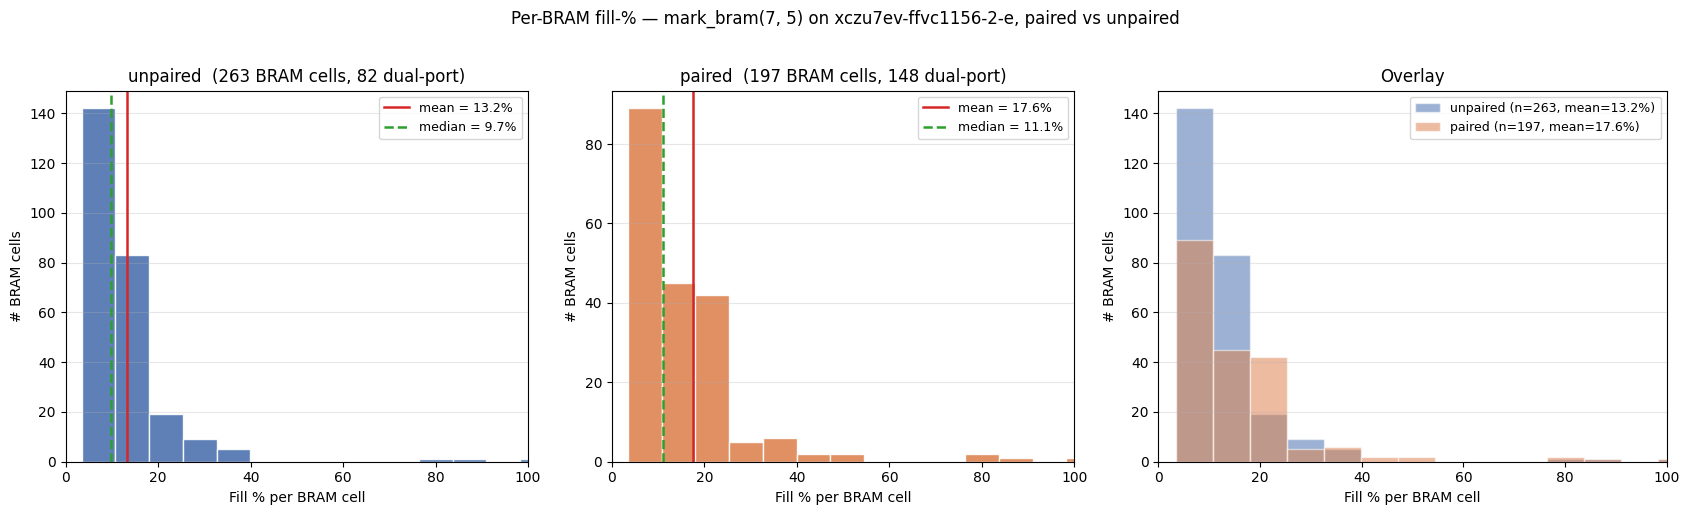


Saved /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/bram_fill/bram_fill_compare.png

=== Headline ===
  unpaired  : 263 BRAM cells, mean fill  13.2%, median   9.7%, total used-bit-equivalent tiles ~263
  paired    : 197 BRAM cells, mean fill  17.6%, median  11.1%, total used-bit-equivalent tiles ~197

  BRAM cell count: unpaired=263  paired=197  reduction = +25.1%
  Mean fill:       unpaired=13.2%  paired=17.6%


In [6]:
import re, shlex, subprocess
import numpy as np
import matplotlib.pyplot as plt

FORCE_RERUN_DUMP = False

# lookup_table_block #(BW_IN, BW_OUT, "mem") inst (...)   — single
_single_pat = re.compile(
    r'lookup_table_block\s*#\s*\(\s*(\d+)\s*,\s*(\d+)\s*,\s*"([^"]+)"\s*\)\s*([A-Za-z_][\w$]*)')
# lookup_table_block_paired #(BW_IN, BW_OUT, "mem") op_pair_A_B (...)
_paired_pat = re.compile(
    r'lookup_table_block_paired\s*#\s*\(\s*(\d+)\s*,\s*(\d+)\s*,\s*"([^"]+)"\s*\)\s*([A-Za-z_][\w$]*)')
# cell name like 'stage18/op_pair_9_22/...' or 'stage7/op_42/...'
_cell_name_pat = re.compile(r'(?:^|/)stage(\d+)/(op_(?:pair_)?\d+(?:_\d+)?)(?:/|$)')


def parse_lookup_blocks(src_dir):
    """Return list of dicts: per emitted ROM instance with static_used_bits."""
    out = []
    for vf in sorted(Path(src_dir).glob('jsc_stage*.v')):
        text = vf.read_text()
        m_stage = re.match(r'jsc_stage(\d+)\.v$', vf.name)
        stage_num = m_stage.group(1) if m_stage else None
        # Paired first (so the bare `lookup_table_block` regex below won't
        # double-count the paired ones — strip them out of the search text).
        paired_spans = []
        for m in _paired_pat.finditer(text):
            bw_in, bw_out, mem, inst = m.groups()
            bw_in, bw_out = int(bw_in), int(bw_out)
            out.append(dict(kind='paired', bw_in=bw_in, bw_out=bw_out, mem_file=mem,
                            instance=inst, stage_num=stage_num,
                            static_used_bits=2 * (1 << bw_in) * bw_out))  # two tables
            paired_spans.append(m.span())
        # Mask paired matches so the single regex skips them.
        masked = list(text)
        for s, e in paired_spans:
            for k in range(s, e): masked[k] = ' '
        masked = ''.join(masked)
        for m in _single_pat.finditer(masked):
            bw_in, bw_out, mem, inst = m.groups()
            bw_in, bw_out = int(bw_in), int(bw_out)
            out.append(dict(kind='single', bw_in=bw_in, bw_out=bw_out, mem_file=mem,
                            instance=inst, stage_num=stage_num,
                            static_used_bits=(1 << bw_in) * bw_out))
    return out


def run_dump_bram(run_dir, force=False):
    run_dir = Path(run_dir)
    dcp = run_dir / 'output_jsc' / 'jsc_post_route.dcp'
    out = run_dir / 'dump_bram.txt'
    if not dcp.exists():
        raise FileNotFoundError(f'missing dcp: {dcp}')
    if not (force or not out.exists() or 'CELL|' not in out.read_text()):
        return out
    cmd = (f'set -e\nsource {shlex.quote(VIVADO_SETTINGS)}\n'
           f'vivado -mode batch -source {shlex.quote(str(DUMP_TCL))} '
           f'-tclargs {shlex.quote(str(dcp))} {shlex.quote(str(out))}\n')
    print(f'[dump_bram] {run_dir.parent.name} ...')
    r = subprocess.run(['bash', '-lc', cmd], cwd=str(run_dir), capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'dump_bram failed:\n{r.stdout}\n{r.stderr}')
    return out


def parse_dump_bram(dump_path):
    cells, cur = [], None
    for line in Path(dump_path).read_text().splitlines():
        if not line.strip():
            if cur is not None: cells.append(cur); cur = None
            continue
        if line.startswith('#'): continue
        if line.startswith('CELL|'):
            parts = line.split('|'); cur = dict(name=parts[1], ref=parts[2], props={})
            for kv in parts[3:]:
                if '=' in kv:
                    k, v = kv.split('=', 1); cur['props'][k] = v
    if cur is not None: cells.append(cur)
    return cells


def fill_pct_per_cell(blocks, cells):
    block_idx = {}
    for i, blk in enumerate(blocks):
        if blk['stage_num'] is None: continue
        block_idx.setdefault((blk['stage_num'], blk['instance']), []).append(i)
    mapping = {c['name']: [] for c in cells}
    matched = set()
    for c in cells:
        m = _cell_name_pat.search(c['name'])
        if not m: continue
        for i in block_idx.get((m.group(1), m.group(2)), []):
            mapping[c['name']].append(i); matched.add(i)
    # Dual-port absorption for Vivado's own packing of leftover singles.
    by_stage = {}
    for i in range(len(blocks)):
        if i in matched or blocks[i]['stage_num'] is None: continue
        by_stage.setdefault(blocks[i]['stage_num'], []).append(i)
    for c in cells:
        if c['props'].get('B_USED', '0') != '1': continue
        m = _cell_name_pat.search(c['name'])
        if not m: continue
        pool = by_stage.get(m.group(1))
        if pool: mapping[c['name']].append(pool.pop(0))
    fills = {}
    for c in cells:
        cap = RAMB_BITS.get(c['ref'])
        if cap is None: continue
        used = sum(blocks[i]['static_used_bits'] for i in mapping[c['name']])
        fills[c['name']] = 100.0 * used / cap
    return fills


# ---- run for both variants ---------------------------------------------------
results = {}
for r in records:
    inner = r['prj_dir']
    blocks = parse_lookup_blocks(inner / 'src')
    dump = run_dump_bram(inner, force=FORCE_RERUN_DUMP)
    cells = parse_dump_bram(dump)
    n_dual = sum(1 for c in cells if c['props'].get('B_USED', '0') == '1')
    fills = fill_pct_per_cell(blocks, cells)
    vals = np.array(list(fills.values()))
    results[r['variant']] = dict(vals=vals, n_cells=len(vals), n_dual=n_dual,
                                 n_blocks=len(blocks),
                                 n_paired=sum(1 for b in blocks if b['kind'] == 'paired'),
                                 n_single=sum(1 for b in blocks if b['kind'] == 'single'))
    print(f'{r["variant"]:<10s}: ROM instances={len(blocks)} '
          f'(single={results[r["variant"]]["n_single"]}, paired={results[r["variant"]]["n_paired"]})  '
          f'BRAM cells={len(cells)} ({n_dual} dual-port)  '
          f'mean fill={vals.mean():.1f}%  median={np.median(vals):.1f}%')

# ---- side-by-side + overlay histograms --------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={'width_ratios': [1, 1, 1.1]})
colors = {'unpaired': '#4c72b0', 'paired': '#dd8452'}

for ax, variant in zip(axes[:2], ['unpaired', 'paired']):
    if variant not in results: continue
    v = results[variant]['vals']
    ax.hist(v, bins=30, color=colors[variant], edgecolor='white', alpha=0.9)
    ax.axvline(v.mean(),   color='#d62728', ls='-',  lw=1.8, label=f'mean = {v.mean():.1f}%')
    ax.axvline(np.median(v), color='#2ca02c', ls='--', lw=1.8, label=f'median = {np.median(v):.1f}%')
    ax.set_title(f'{variant}  ({results[variant]["n_cells"]} BRAM cells, '
                 f'{results[variant]["n_dual"]} dual-port)')
    ax.set_xlabel('Fill % per BRAM cell'); ax.set_ylabel('# BRAM cells')
    ax.set_xlim(0, 100); ax.grid(True, axis='y', alpha=0.3); ax.legend(fontsize=9)

# overlay
axc = axes[2]
for variant in ['unpaired', 'paired']:
    if variant not in results: continue
    v = results[variant]['vals']
    axc.hist(v, bins=30, color=colors[variant], alpha=0.55, edgecolor='white',
             label=f'{variant} (n={results[variant]["n_cells"]}, mean={v.mean():.1f}%)')
axc.set_title('Overlay'); axc.set_xlabel('Fill % per BRAM cell'); axc.set_ylabel('# BRAM cells')
axc.set_xlim(0, 100); axc.grid(True, axis='y', alpha=0.3); axc.legend(fontsize=9)

plt.suptitle(f'Per-BRAM fill-% — mark_bram{BRAM_THR} on {PART_NAME}, paired vs unpaired', y=1.02)
plt.tight_layout()
out_png = NB_DIR / 'bram_fill_compare.png'
plt.savefig(out_png, dpi=130, bbox_inches='tight')
plt.show()
print(f'\nSaved {out_png}')

# ---- headline numbers --------------------------------------------------------
print('\n=== Headline ===')
for variant in ['unpaired', 'paired']:
    if variant not in results: continue
    v = results[variant]['vals']
    print(f'  {variant:<10s}: {results[variant]["n_cells"]:>3d} BRAM cells, '
          f'mean fill {v.mean():5.1f}%, median {np.median(v):5.1f}%, '
          f'total used-bit-equivalent tiles ~{results[variant]["n_cells"]}')
if 'unpaired' in results and 'paired' in results:
    nu, npd = results['unpaired']['n_cells'], results['paired']['n_cells']
    print(f'\n  BRAM cell count: unpaired={nu}  paired={npd}  '
          f'reduction = {100*(nu-npd)/nu:+.1f}%')
    print(f'  Mean fill:       unpaired={results["unpaired"]["vals"].mean():.1f}%  '
          f'paired={results["paired"]["vals"].mean():.1f}%')


Side-by-side full stats: resources, latency, Fmax, power.

In [ ]:
import json, re as _re
import numpy as np
import pandas as pd

def _u_used(t, label):
    m = _re.search(r'^\|\s*' + _re.escape(label) + r'\s*\|\s*([\d.]+)\s*\|', t, _re.MULTILINE)
    return float(m.group(1)) if m else float('nan')

def _u_avail(t, label):
    m = _re.search(r'^\|\s*' + _re.escape(label) + r'\s*\|\s*[\d.]+\s*\|[^|]+\|[^|]+\|\s*([\d.]+)\s*\|',
                   t, _re.MULTILINE)
    return float(m.group(1)) if m else float('nan')

def _wns(path):
    if not path.exists(): return float('nan')
    m = _re.search(r'WNS\(ns\)[^\n]*\n[^\n]*\n\s*([-\d.]+)', path.read_text())
    return float(m.group(1)) if m else float('nan')

def _power(path):
    if not path.exists(): return float('nan')
    m = _re.search(r'Total On-Chip Power \(W\)\s*\|\s*([\d.]+)', path.read_text())
    return float(m.group(1)) if m else float('nan')

rows = []
for r in records:
    rep = r['prj_dir'] / 'output_jsc' / 'reports'
    util = rep / 'jsc_post_route_util.rpt'
    meta = json.loads((r['prj_dir'] / 'metadata.json').read_text())
    cycles = meta.get('latency', float('nan'))
    ut = util.read_text() if util.exists() else ''
    wns_pp = _wns(rep / 'jsc_post_place_timing.rpt')
    wns_pr = _wns(rep / 'jsc_post_route_tire [{bw_b - 1}:ming.rpt')
    fmax_pp = 1000.0 / (CLOCK_PERIOD - wns_pp) if wns_pp == wns_pp and (CLOCK_PERIOD - wns_pp) > 0 else float('nan')
    fmax_pr = 1000.0 / (CLOCK_PERIOD - wns_pr) if wns_pr == wns_pr and (CLOCK_PERIOD - wns_pr) > 0 else float('nan')
    lat_ns = cycles / fmax_pr * 1000.0 if fmax_pr == fmax_pr else float('nan')
    rows.append(dict(
        variant=r['variant'],
        lut=_u_used(ut, 'CLB LUTs'), lut_avail=_u_avail(ut, 'CLB LUTs'),
        ff=_u_used(ut, 'CLB Registers'),
        bram_tiles=_u_used(ut, 'Block RAM Tile'), bram_avail=_u_avail(ut, 'Block RAM Tile'),
        dsp=_u_used(ut, 'DSPs'),
        cycles=cycles, latency_ns=lat_ns,
        wns_pp=wns_pp, fmax_pp_MHz=fmax_pp,
        wns_pr=wns_pr, fmax_pr_MHz=fmax_pr,
        power_W=_power(rep / 'jsc_post_route_power.rpt'),
        rtl_single=r['rtl_single'], rtl_paired=r['rtl_paired'],
        ir_bram=r['n_bram'], ir_paired_hint=r['n_hint'],
    ))

df_stats = pd.DataFrame(rows).set_index('variant')
if df_stats['lut'].notna().any():
    df_stats.to_csv(NB_DIR / 'bram_fill_stats.csv')
else:
    # No Vivado reports on disk: keep the committed results instead of clobbering them.
    df_stats = pd.read_csv(NB_DIR / 'bram_fill_stats.csv', index_col='variant')
    print('no Vivado reports found; loaded committed bram_fill_stats.csv')

fmt = {c: '{:.0f}'.format for c in ['lut','lut_avail','ff','dsp','cycles','rtl_single','rtl_paired','ir_bram','ir_paired_hint','bram_avail']}
fmt.update({'bram_tiles':'{:.1f}'.format, 'latency_ns':'{:.1f}'.format,
            'wns_pp':'{:+.3f}'.format, 'fmax_pp_MHz':'{:.1f}'.format,
            'wns_pr':'{:+.3f}'.format, 'fmax_pr_MHz':'{:.1f}'.format, 'power_W':'{:.3f}'.format})
print('Full stats (post-route, both variants):\n')
print(df_stats.T.to_string(na_rep='-'))

if {'unpaired','paired'} <= set(df_stats.index):
    u, p = df_stats.loc['unpaired'], df_stats.loc['paired']
    print('\n=== Deltas (paired vs unpaired) ===')
    print(f'  BRAM tiles : {u["bram_tiles"]:.1f} -> {p["bram_tiles"]:.1f}  '
          f'({100*(p["bram_tiles"]-u["bram_tiles"])/u["bram_tiles"]:+.1f}%)')
    print(f'  LUT        : {u["lut"]:.0f} -> {p["lut"]:.0f}  ({100*(p["lut"]-u["lut"])/u["lut"]:+.2f}%)')
    print(f'  FF         : {u["ff"]:.0f} -> {p["ff"]:.0f}')
    print(f'  Fmax (pr)  : {u["fmax_pr_MHz"]:.1f} -> {p["fmax_pr_MHz"]:.1f} MHz')
    print(f'  Power      : {u["power_W"]:.3f} -> {p["power_W"]:.3f} W')
    print(f'  Latency    : {u["latency_ns"]:.1f} -> {p["latency_ns"]:.1f} ns')


Full stats (post-route, both variants):

variant              unpaired         paired
lut              32965.000000   33094.000000
lut_avail       230400.000000  230400.000000
ff               45322.000000   45236.000000
bram_tiles         132.500000      99.500000
bram_avail         312.000000     312.000000
dsp                  0.000000       0.000000
cycles              30.000000      30.000000
latency_ns          92.550000      79.650000
wns_pp              -0.538000      -0.091000
fmax_pp_MHz        329.163924     385.951370
wns_pr              -0.585000      -0.155000
fmax_pr_MHz        324.149109     376.647834
power_W              5.353000       5.397000
rtl_single         344.000000      48.000000
rtl_paired           0.000000     148.000000
ir_bram            344.000000     344.000000
ir_paired_hint       0.000000     344.000000

=== Deltas (paired vs unpaired) ===
  BRAM tiles : 132.5 -> 99.5  (-24.9%)
  LUT        : 32965 -> 33094  (+0.39%)
  FF         : 45322 -> 45236
  F

Verilator bit-accuracy check, one per variant.

In [11]:
import shutil, tempfile
import numpy as np
from data import get_data
from da4ml.cmvm import dsp_offload
from da4ml.converter import trace_model
from da4ml.trace import HWConfig, comb_trace, mark_bram, mark_dsp
from da4ml.codegen import RTLModel

# ---- test batch -------------------------------------------------------------
N_TEST = 2000   # raise for a stricter check; 2000 is plenty for bit-exactness
(_, _), (_, _), (X_test, y_test) = get_data(DATA_DIR, 64, FEATURES == 3)
X_test = np.asarray(X_test)[:N_TEST]
y_test = np.asarray(y_test)[:N_TEST]
print(f'Test batch: X={X_test.shape}')

_HW = HWConfig(1, -1, -1)
_DSP = dsp_offload(min_csd_terms=2, min_var_bits=4, max_const_bits=18, max_ops=None)
_SO = {'hard_dc': 2, 'dsp_offload_fn': _DSP}
bi, bo = BRAM_THR

def _build_comb(pair):
    inp, out = trace_model(model, hwconf=_HW, solver_options=_SO, verbose=False)
    comb = comb_trace(inp, out)
    comb = mark_bram(comb,
                     predicate=lambda bw_in, bw_out, bi=bi, bo=bo: bw_in >= bi and bw_out >= bo,
                     latency_cutoff=LATENCY_CUTOFF, pair_within_stage=pair)
    comb = mark_dsp(comb, predicate=lambda *_: True, latency_cutoff=LATENCY_CUTOFF)
    return comb

veri = {}
scratch = Path(tempfile.mkdtemp(prefix='bram_fill_verilator_'))
try:
    for variant, pair in VARIANTS:
        comb = _build_comb(pair)
        sw = comb.predict(X_test, n_threads=-1)            # SW reference (IR emulation)

        out_path = scratch / variant
        out_path.mkdir(parents=True, exist_ok=True)
        rtl = RTLModel(comb, MODEL_NAME, str(out_path),
                       latency_cutoff=LATENCY_CUTOFF, clock_period=CLOCK_PERIOD,
                       part_name=PART_NAME, clock_uncertainty=0.0)
        rtl.write()
        for _ in range(8):
            try:
                rtl._compile(openmp=False, nproc=4); break
            except RuntimeError:
                pass
        hw = rtl.predict(X_test)                            # Verilator-compiled

        ndiff = int(np.sum(hw != sw))
        veri[variant] = dict(sw=sw, hw=hw, ndiff=ndiff)
        y_ref = y_test if y_test.ndim == 1 else np.argmax(y_test, axis=1)
        acc = float(np.mean(np.argmax(hw, axis=1) == y_ref))
        print(f'{variant:<10s}: rtl(verilator) vs comb(SW) diffs = {ndiff} / {hw.size}'
              f'   accuracy(hw) = {acc*100:.3f}%')
        assert ndiff == 0, f'{variant}: Verilator output != SW IR output!'

    # Cross-variant: pairing must not change a single bit.
    if {'unpaired','paired'} <= set(veri):
        xdiff = int(np.sum(veri['paired']['hw'] != veri['unpaired']['hw']))
        print(f'\npaired vs unpaired (Verilator): {xdiff} / {veri["paired"]["hw"].size} differing values')
        assert xdiff == 0, 'paired and unpaired RTL differ — pairing is NOT bit-exact!'
        print('✓ Bit-exact: Verilator(paired) == Verilator(unpaired) == SW IR. '
              'BRAM pairing changes zero output bits.')
finally:
    shutil.rmtree(scratch, ignore_errors=True)


Test batch: X=(2000, 64, 16)
unpaired  : rtl(verilator) vs comb(SW) diffs = 0 / 10000   accuracy(hw) = 81.300%
paired    : rtl(verilator) vs comb(SW) diffs = 0 / 10000   accuracy(hw) = 81.300%

paired vs unpaired (Verilator): 0 / 10000 differing values
✓ Bit-exact: Verilator(paired) == Verilator(unpaired) == SW IR. BRAM pairing changes zero output bits.


Optional cocotb simulation cross-check.

In [12]:
import importlib.util, sys
if importlib.util.find_spec('cocotb') is None or (
        importlib.util.find_spec('cocotb_tools') is None and importlib.util.find_spec('cocotb.runner') is None):
    print('cocotb / runner API not available — skipping. (pip install cocotb to enable.)')
else:
    import json, os, shutil
    import numpy as np
    import xml.etree.ElementTree as ET
    from data import get_data
    from da4ml.cmvm import dsp_offload
    from da4ml.converter import trace_model
    from da4ml.trace import HWConfig, comb_trace, mark_bram, mark_dsp
    try:
        from cocotb_tools.runner import get_runner   # cocotb >= 2.0
    except ImportError:
        from cocotb.runner import get_runner          # cocotb 1.x

    N_COCOTB        = 64
    COCOTB_VARIANTS = ['paired']    # set to ['unpaired', 'paired'] to test both
    DA4ML_GRID      = HGQ_JSC150   # holds cocotb_jsc_test_runner.py
    if str(DA4ML_GRID) not in sys.path:
        sys.path.insert(0, str(DA4ML_GRID))

    (_, _), (_, _), (Xc, _yc) = get_data(DATA_DIR, 64, FEATURES == 3)
    Xc = np.asarray(Xc)[:N_COCOTB]
    in_shape = model.input_shape[1:]   # e.g. (64, 16)

    _HW = HWConfig(1, -1, -1)
    _SO = {'hard_dc': 2, 'dsp_offload_fn': dsp_offload(min_csd_terms=2, min_var_bits=4, max_const_bits=18, max_ops=None)}
    bi, bo = BRAM_THR

    def _comb_for(pair):
        inp, out = trace_model(model, hwconf=_HW, solver_options=_SO, verbose=False)
        c = comb_trace(inp, out)
        c = mark_bram(c, predicate=lambda a, b, bi=bi, bo=bo: a >= bi and b >= bo,
                      latency_cutoff=LATENCY_CUTOFF, pair_within_stage=pair)
        c = mark_dsp(c, predicate=lambda *_: True, latency_cutoff=LATENCY_CUTOFF)
        return c

    def _pack(int_vals, kifs, slot_w, lsb_ref):
        """Uniform-slot packing — mirrors da4ml's io_wrapper / the grid driver."""
        big = 0
        for j, v in enumerate(int_vals):
            k, i, f = int(kifs[0, j]), int(kifs[1, j]), int(kifs[2, j])
            bw = k + i + f
            if bw <= 0:
                continue
            v_uint = int(v) & ((1 << bw) - 1)
            big |= (v_uint << (lsb_ref - f)) << (slot_w * j)
        return big

    overall_ok = True
    for variant in COCOTB_VARIANTS:
        pair = dict(VARIANTS)[variant]
        run_dir = NB_DIR / variant / model_stem
        src     = run_dir / 'src'
        comb    = _comb_for(pair)

        inp_kifs = np.asarray(comb.inp_kifs)   # (3, n_in): rows k, i, f
        out_kifs = np.asarray(comb.out_kifs)   # (3, n_out)
        n_in, n_out = inp_kifs.shape[1], out_kifs.shape[1]
        # Slot geometry (matches hetero_io_map: slot_w = max(k+i)+max(f), lsb_ref = max(f)).
        in_slot_w  = int((inp_kifs[0] + inp_kifs[1]).max() + inp_kifs[2].max())
        in_lsb_ref = int(inp_kifs[2].max())
        out_slot_w = int((out_kifs[0] + out_kifs[1]).max() + out_kifs[2].max())
        out_lsb_ref = int(out_kifs[2].max())
        latency = int(json.loads((run_dir / 'metadata.json').read_text())['latency'])

        # Quantise real samples to each input's fixed-point scale, then pack.
        Xflat = Xc.reshape(Xc.shape[0], -1)
        int_inputs = np.zeros((len(Xflat), n_in), dtype=np.int64)
        for j in range(n_in):
            f = int(inp_kifs[2, j])
            int_inputs[:, j] = np.round(Xflat[:, j] * (2.0 ** f)).astype(np.int64)
        float_view = (int_inputs.astype(np.float64)
                      * (2.0 ** -inp_kifs[2].astype(np.float64))[None, :]).reshape(len(Xflat), *in_shape)
        float_out = comb.predict(float_view, n_threads=1)
        int_expected = np.zeros((len(Xflat), n_out), dtype=np.int64)
        for j in range(n_out):
            int_expected[:, j] = np.round(float_out[:, j] * (2.0 ** int(out_kifs[2, j]))).astype(np.int64)
        packed_inputs = [_pack(int_inputs[s], inp_kifs, in_slot_w, in_lsb_ref) for s in range(len(Xflat))]

        # Sidecars consumed by cocotb_jsc_test_runner.py (via TEST_DATA_DIR).
        sim_dir = NB_DIR / f'_cocotb_sim_{variant}'
        sim_build = sim_dir / 'sim_build'
        sim_build.mkdir(parents=True, exist_ok=True)
        np.savez(sim_dir / 'test_vectors.npz',
                 model_inp=np.array(packed_inputs, dtype=object),
                 expected=int_expected)
        (sim_dir / 'test_config.json').write_text(json.dumps({
            'latency': latency, 'clock_period_ns': float(CLOCK_PERIOD),
            'out_bws': (out_kifs[0] + out_kifs[1] + out_kifs[2]).astype(int).tolist(),
            'out_fs':  out_kifs[2].astype(int).tolist(),
            'out_ks':  out_kifs[0].astype(int).tolist(),
            'out_slot_w': out_slot_w, 'out_lsb_ref': out_lsb_ref,
        }, indent=2))
        for mf in (src / 'memfiles').glob('*.mem'):
            shutil.copy(mf, sim_dir / mf.name)   # $readmemh resolves cwd-relative

        sources = sorted(src.glob('*.v')) + sorted((src / 'static').glob('*.v'))
        print(f'=== cocotb [{variant}] : {len(packed_inputs)} samples, latency={latency}, '
              f'in_slot_w={in_slot_w}, out_slot_w={out_slot_w}, {len(sources)} sources ===')

        runner = get_runner('verilator')
        runner.build(sources=[str(s) for s in sources], hdl_toplevel='jsc_wrapper',
                     build_args=['-Wno-fatal', '-Wno-WIDTHEXPAND', '-Wno-WIDTHTRUNC',
                                 '-Wno-UNUSEDSIGNAL', '-Wno-CASEINCOMPLETE'],
                     always=True, build_dir=str(sim_build))
        results_xml = runner.test(hdl_toplevel='jsc_wrapper',
                                  test_module='cocotb_jsc_test_runner',
                                  build_dir=str(sim_build), test_dir=str(sim_dir),
                                  extra_env={'TEST_DATA_DIR': str(sim_dir)})

        root = ET.parse(results_xml).getroot()
        for tc in root.iter('testcase'):
            failed = tc.find('failure') is not None or tc.find('error') is not None
            overall_ok = overall_ok and not failed
            print(f'  [{variant}] {tc.get("name"):<28s} {"FAIL" if failed else "PASS"}'
                  f'  ({float(tc.get("time", 0)):.2f}s)')

    print(f'\ncocotb overall: {"ALL PASSED" if overall_ok else "FAILED — see _cocotb_sim_*/sim.log"}')
    assert overall_ok, 'cocotb RTL simulation mismatch'


=== cocotb [paired] : 64 samples, latency=30, in_slot_w=18, out_slot_w=13, 43 sources ===
- V e r i l a t i o n   R e p o r t: Verilator 5.032 2025-01-01 rev (Debian 5.032-1)
- Verilator: Built from 104.472 MB sources in 44 modules, into 152.891 MB in 79 C++ files needing 0.003 MB
- Verilator: Walltime 16.894 s (elab=1.471, cvt=14.245, bld=0.000); cpu 16.892 s on 1 threads; alloced 715.188 MB
make: Entering directory '/home/kevin/Dev/Imperial/HGQ2-examples/jsc150/bram_fill/_cocotb_sim_paired/sim_build'
g++  -I.  -MMD -I/usr/share/verilator/include -I/usr/share/verilator/include/vltstd -DVM_COVERAGE=0 -DVM_SC=0 -DVM_TIMING=0 -DVM_TRACE=0 -DVM_TRACE_FST=0 -DVM_TRACE_VCD=0 -faligned-new -fcf-protection=none -Wno-bool-operation -Wno-shadow -Wno-sign-compare -Wno-tautological-compare -Wno-uninitialized -Wno-unused-but-set-parameter -Wno-unused-but-set-variable -Wno-unused-parameter -Wno-unused-variable      -Os  -c -o verilator.o /home/kevin/venvs/ml5090-312/lib/python3.12/site-packages/coc